# %% [markdown]
# ## 1. Récupération des TKI cliniques via l'API ChEMBL
# On va chercher les SMILES canoniques d’Erlotinib, Gefitinib, Afatinib et Osimertinib


In [1]:
#!pip install chembl_webresource_client

In [2]:
# %% [code]
import requests
import pandas as pd

tkis = ["Erlotinib", "Gefitinib", "Afatinib", "Osimertinib"]
records = []

for name in tkis:
    url = (
        "https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/"
        f"name/{name}/property/CanonicalSMILES/JSON"
    )
    resp = requests.get(url)
    try:
        resp.raise_for_status()
    except requests.HTTPError as e:
        print(f"⚠️  HTTP error pour {name}: {e}")
        continue

    data = resp.json()
    props = data.get("PropertyTable", {}).get("Properties", [])
    if not props:
        print(f"⚠️  Pas de PropertyTable.Properties pour {name}")
        continue

    rec = props[0]
    # Recherche de la clé SMILES quelle qu’elle soit
    smiles = None
    for k, v in rec.items():
        if "SMILES" in k.upper():
            smiles = v
            break

    if not smiles:
        print(f"⚠️  Aucune clé SMILES trouvée pour {name}. Clés disponibles: {list(rec.keys())}")
        continue

    records.append({
        "name": name,
        "smiles": smiles
    })

tkis_df = pd.DataFrame(records)
tkis_df.to_csv("data/tkis.csv", index=False)
tkis_df


,name,smiles
0,Erlotinib,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...
1,Gefitinib,COC1=C(C=C2C(=C1)N=CN=C2NC3=CC(=C(C=C3)F)Cl)OC...
2,Afatinib,CN(C)CC=CC(=O)NC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC(...
3,Osimertinib,CN1C=C(C2=CC=CC=C21)C3=NC(=NC=C3)NC4=C(C=C(C(=...


In [3]:
# %% [code]
import requests
import pandas as pd
import time

# 1) Récupération paginée des IC50
BASE_ACT = "https://www.ebi.ac.uk/chembl/api/data/activity"
LIMIT = 1000
offset = 0
records = []

print("🔄 Récupération des activités IC50…")
while True:
    params = {
        "target_chembl_id": "CHEMBL203",
        "standard_type": "IC50",
        "standard_relation": "=",
        "standard_value__isnull": "false",
        "limit": LIMIT,
        "offset": offset,
        "format": "json"
    }
    r = requests.get(BASE_ACT, params=params)
    r.raise_for_status()
    data = r.json().get("activities", [])
    if not data:
        break

    for a in data:
        val = float(a["standard_value"])
        if val > 1000:  # filtrage précoce
            continue
        records.append({
            "chembl_id": a["molecule_chembl_id"],
            "ic50": val,
            "units": a["standard_units"]
        })

    offset += LIMIT
    time.sleep(0.5)

egfr_act_df = (
    pd.DataFrame(records)
      .drop_duplicates("chembl_id")
      .reset_index(drop=True)
)
print(f"✅ Activités récupérées : {len(egfr_act_df)} molécules")

# 2) Fonction robuste pour récupérer les SMILES en batch
BASE_MOL = "https://www.ebi.ac.uk/chembl/api/data/molecule"
def fetch_smiles_batch(ids_chunk):
    url = BASE_MOL + ".json"
    params = {
        "molecule_chembl_id__in": ",".join(ids_chunk),
        "format": "json"
    }
    r = requests.get(url, params=params)
    if r.status_code == 400 and len(ids_chunk) > 1:
        # découper le lot et fusionner
        mid = len(ids_chunk) // 2
        return {
            **fetch_smiles_batch(ids_chunk[:mid]),
            **fetch_smiles_batch(ids_chunk[mid:])
        }
    r.raise_for_status()
    mols = r.json().get("molecules", [])
    return {
        m["molecule_chembl_id"]: m["molecule_structures"]["canonical_smiles"]
        for m in mols
    }

# 3) Récupération des SMILES
ids = egfr_act_df["chembl_id"].tolist()
smiles_map = {}
batch_size = 100

print("🔄 Récupération des SMILES en batch…")
for i in range(0, len(ids), batch_size):
    chunk = ids[i : i + batch_size]
    smiles_map.update(fetch_smiles_batch(chunk))
    time.sleep(0.5)

# 4) Assemblage final et sauvegarde
egfr_act_df["smiles"] = egfr_act_df["chembl_id"].map(smiles_map)
egfr_act_df = egfr_act_df.dropna(subset=["smiles"])
print(f"✅ Final dataset: {len(egfr_act_df)} molécules avec SMILES")

egfr_act_df.to_csv("data/egfr_chembl_actives.csv", index=False)
egfr_act_df.head()


🔄 Récupération des activités IC50…


KeyboardInterrupt: 

In [ ]:
import sys
# Ajoute le parent du dossier notebooks (le root de ton projet) au PYTHONPATH
sys.path.append('..')


In [ ]:
# %% [code]
import pandas as pd
from pathlib import Path

# 1) Paramètres de chemin
DATA_DIR     = Path("data")       # notebooks/data
ARTIFACT_DIR = Path("artifacts")  # notebooks/artifacts
ARTIFACT_DIR.mkdir(exist_ok=True)

# 2) Imports de ton module src
from src.preprocessing import (
    process_smiles, compute_ecfp4,
    apply_lipinski_filter, apply_pains_filter
)

# 3) Chargement de la librairie brute
lib = pd.read_csv(DATA_DIR / "egfr_chembl_actives.csv")
print(f"🔹 Brute : {len(lib)} molécules")

# 4) Standardisation & featurisation
lib["smiles_clean"] = lib["smiles"].apply(process_smiles)
lib = lib.dropna(subset=["smiles_clean"]).reset_index(drop=True)
lib["fp"] = lib["smiles_clean"].apply(compute_ecfp4)
print(f"🔹 Nettoyée & fingerprintée : {len(lib)} molécules")

# 5) Sauvegarde intermédiaire en pickle (garde les listes intactes)
cleaned_path = ARTIFACT_DIR / "01_lib_cleaned.pkl"
lib.to_pickle(cleaned_path)
print(f"💾 Écrit {cleaned_path.name}")

# 6) Filtrage Lipinski + PAINS
lib_lip = apply_lipinski_filter(lib, smiles_col="smiles_clean")
print(f"🔹 Après Lipinski : {len(lib_lip)} molécules")
lib_filt = apply_pains_filter(lib_lip, smiles_col="smiles_clean")
print(f"🔹 Après PAINS    : {len(lib_filt)} molécules")

# 7) Sauvegarde finale en pickle
filtered_path = ARTIFACT_DIR / "02_lib_filtered.pkl"
lib_filt.to_pickle(filtered_path)
print(f"💾 Écrit {filtered_path.name}")


🔹 Brute : 1160 molécules
🔹 Nettoyée & fingerprintée : 1160 molécules
💾 Écrit 01_lib_cleaned.pkl
🔹 Après Lipinski : 604 molécules
🔹 Après PAINS    : 545 molécules
💾 Écrit 02_lib_filtered.pkl


In [ ]:
print("Aperçu du fichier 01_lib_cleaned.csv :")
display(pd.read_csv(cleaned_path).head(2))

print("Aperçu du fichier 02_lib_filtered.csv :")
display(pd.read_csv(filtered_path).head(2))

Aperçu du fichier 01_lib_cleaned.csv :


UnicodeDecodeError: 'utf-8' codec can't decode byte 0x80 in position 0: invalid start byte

In [ ]:
!ls artifacts/

01_lib_cleaned.csv  02_lib_filtered.csv


In [5]:
# %% [code]
import sys
from pathlib import Path
import pandas as pd

# 1) Assure-toi que src/ est dans ton PYTHONPATH
sys.path.append("..")

# 2) Définitions des dossiers
DATA_DIR     = Path("data")      # notebooks/data
ARTIFACT_DIR = Path("artifacts") # notebooks/artifacts

# 3) Imports des fonctions
from src.preprocessing import compute_ecfp4
from src.similarity     import calculate_tanimoto, select_top_n

# 4) Chargement de la librairie filtrée
lib = pd.read_pickle(ARTIFACT_DIR / "02_lib_filtered.pkl")
if lib.empty:
    raise ValueError("La librairie est vide après filtrage !")
print(f"💾 Librairie prête : {len(lib)} molécules")

# 5) S’assurer que les empreintes ECFP4 sont bien calculées
if "fp" not in lib.columns:
    lib["fp"] = lib["smiles_clean"].apply(compute_ecfp4)

# 6) Chargement des TKI de référence
tkis = pd.read_csv(DATA_DIR / "tkis.csv")

# 7) Pour chaque TKI : calcul de similarité et top‑50
for _, row in tkis.iterrows():
    name       = row["name"]
    query_smi  = row["smiles"]
    # Empreinte de la molécule query
    query_fp   = compute_ecfp4(query_smi)

    # Calcul de la similarité Tanimoto
    sim = lib.copy()
    sim["tanimoto"] = sim["fp"].apply(lambda x: calculate_tanimoto(x, query_fp))

    # Sélection des 50 meilleurs
    top50 = select_top_n(sim, metric="tanimoto", n=50)
    out_path = ARTIFACT_DIR / f"03_top50_{name}.csv"
    top50.to_csv(out_path, index=False)
    print(f"✔️  Top50 pour {name} enregistré dans {out_path.name}")


💾 Librairie prête : 545 molécules
✔️  Top50 pour Erlotinib enregistré dans 03_top50_Erlotinib.csv
✔️  Top50 pour Gefitinib enregistré dans 03_top50_Gefitinib.csv
✔️  Top50 pour Afatinib enregistré dans 03_top50_Afatinib.csv
✔️  Top50 pour Osimertinib enregistré dans 03_top50_Osimertinib.csv


In [7]:
top50_erlo = pd.read_csv(ARTIFACT_DIR / "03_top50_Erlotinib.csv")
tkis = pd.read_csv(DATA_DIR / "tkis.csv")
query = tkis[tkis["name"]=="Erlotinib"]["smiles"].iloc[0]
hit   = top50_erlo.loc[0, "smiles_clean"]
print(query, hit)


COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C)OCCOC C#CC1=CC=CC(NC2=NC=NC3=CC(OCCOC)=C(OCCOC)C=C32)=C1


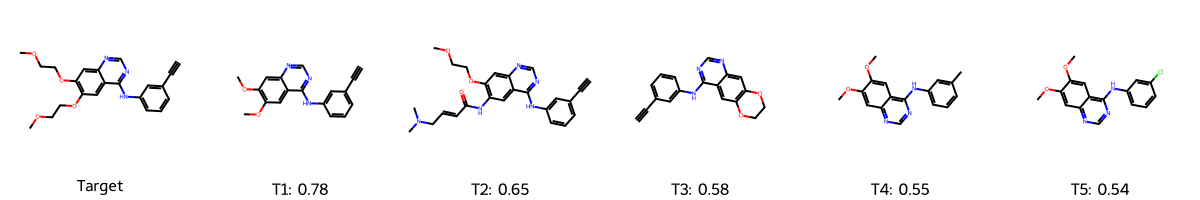

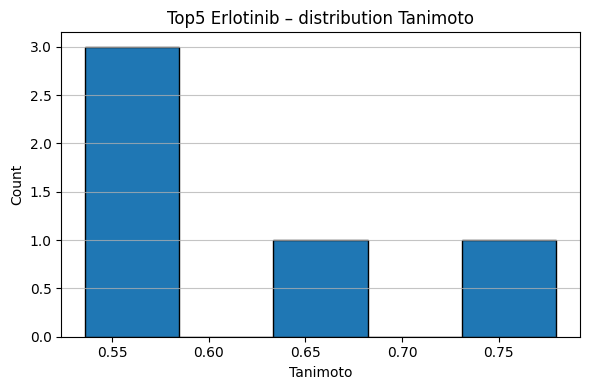

In [8]:
# %% [code]
import sys
from pathlib import Path
import pandas as pd
from IPython.display import SVG, display

# 2) Imports utilitaires
from src.preprocessing import (
    draw_target_vs_hits,
    plot_similarity_histogram
)

# 3) Chemins
DATA_DIR = Path("data")
ART_DIR  = Path("artifacts")

# 4) Récupérer le SMILES d'Erlotinib depuis tkis.csv
tkis     = pd.read_csv(DATA_DIR / "tkis.csv")
erlo_smi = tkis.loc[tkis["name"] == "Erlotinib", "smiles"].iloc[0]

# 5) Charger le top50 d'Erlotinib
top50_erlo = pd.read_csv(ART_DIR / "03_top50_Erlotinib.csv")

# 6) Sélectionner les 5 meilleurs hits (excluant le self-match)
hits      = top50_erlo[top50_erlo["tanimoto"] < 1.0].head(5)
hit_smis  = hits["smiles_clean"].tolist()
hit_scores= hits["tanimoto"].tolist()

# 7) Dessin cible vs hits
svg_str = draw_target_vs_hits(
    target_smiles=erlo_smi,
    hits_smiles=hit_smis,
    scores=hit_scores,
    mols_per_row=6,
    sub_img_size=(200,200),
    legend_prefix="T"
)
display(SVG(data=svg_str))

# 8) Histogramme des scores
plot_similarity_histogram(
    hit_scores,
    bins=5,
    title="Top5 Erlotinib – distribution Tanimoto",
    xlabel="Tanimoto",
    ylabel="Count"
)


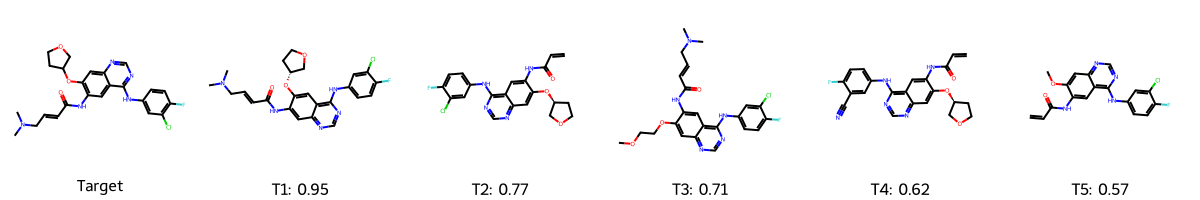

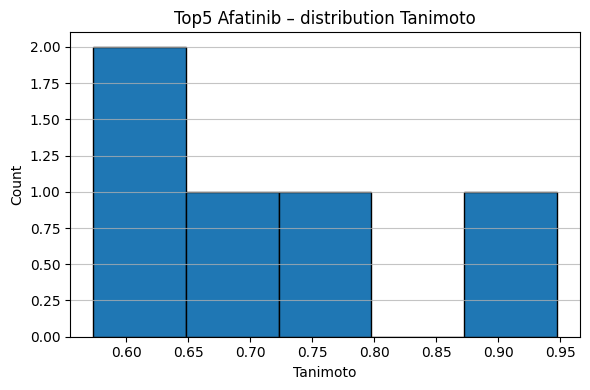

In [ ]:
# %% [code]
import sys
from pathlib import Path
import pandas as pd
from IPython.display import SVG, display

# 1) Pour voir src/
sys.path.append("..")

# 2) Imports utilitaires
from src.preprocessing import (
    draw_target_vs_hits,
    plot_similarity_histogram
)

# 3) Chemins
DATA_DIR = Path("data")
ART_DIR  = Path("artifacts")


# 4) Récupérer le SMILES depuis tkis.csv
tkis     = pd.read_csv(DATA_DIR / "tkis.csv")
erlo_smi = tkis.loc[tkis["name"] == "Afatinib", "smiles"].iloc[0]

# 5) Charger le top50 d'Erlotinib
top50_erlo = pd.read_csv(ART_DIR / "03_top50_Afatinib.csv")

# 6) Sélectionner les 5 meilleurs hits (excluant le self-match)
hits      = top50_erlo[top50_erlo["tanimoto"] < 1.0].head(5)
hit_smis  = hits["smiles_clean"].tolist()
hit_scores= hits["tanimoto"].tolist()

# 7) Dessin cible vs hits
svg_str = draw_target_vs_hits(
    target_smiles=erlo_smi,
    hits_smiles=hit_smis,
    scores=hit_scores,
    mols_per_row=6,
    sub_img_size=(200,200),
    legend_prefix="T"
)
display(SVG(data=svg_str))

# 8) Histogramme des scores
plot_similarity_histogram(
    hit_scores,
    bins=5,
    title="Top5 Afatinib – distribution Tanimoto",
    xlabel="Tanimoto",
    ylabel="Count"
)


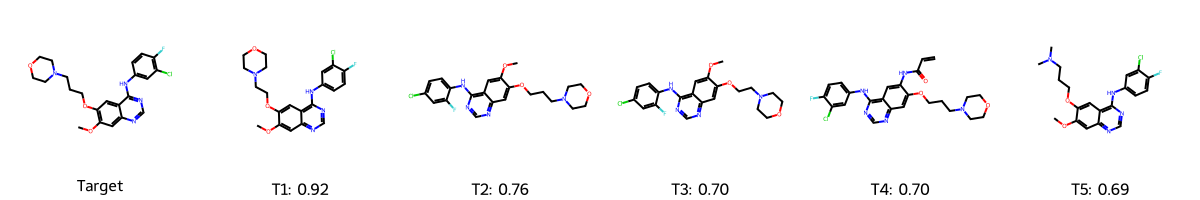

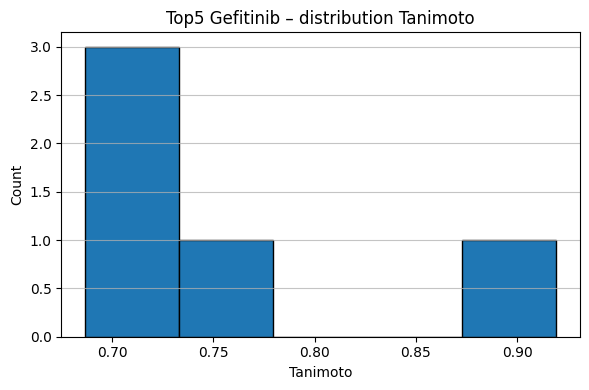

In [13]:

# 4) Récupérer le SMILES depuis tkis.csv
tkis     = pd.read_csv(DATA_DIR / "tkis.csv")
gef_smi = tkis.loc[tkis["name"] == "Gefitinib", "smiles"].iloc[0]

# 5) Charger le top50 d'Erlotinib
top50_gef = pd.read_csv(ART_DIR / "03_top50_Gefitinib.csv")

# 6) Sélectionner les 5 meilleurs hits (excluant le self-match)
hits      = top50_gef[top50_gef["tanimoto"] < 1.0].head(5)
hit_smis  = hits["smiles_clean"].tolist()
hit_scores= hits["tanimoto"].tolist()

# 7) Dessin cible vs hits
svg_str = draw_target_vs_hits(
    target_smiles=gef_smi,
    hits_smiles=hit_smis,
    scores=hit_scores,
    mols_per_row=6,
    sub_img_size=(200,200),
    legend_prefix="T"
)
display(SVG(data=svg_str))

# 8) Histogramme des scores
plot_similarity_histogram(
    hit_scores,
    bins=5,
    title="Top5 Gefitinib – distribution Tanimoto",
    xlabel="Tanimoto",
    ylabel="Count"
)


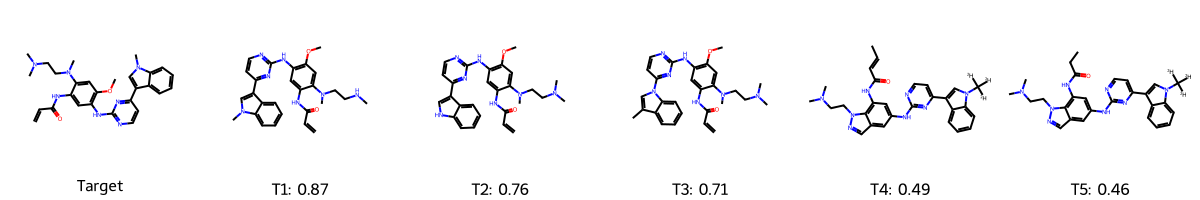

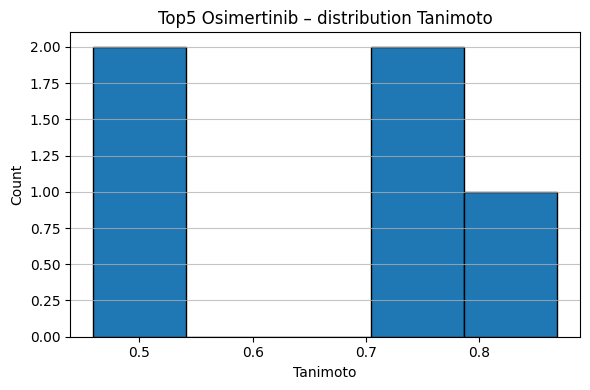

In [12]:
osi_smi = tkis.loc[tkis["name"] == "Osimertinib", "smiles"].iloc[0]

# 5) Charger le top50 d'Erlotinib
top50_osi = pd.read_csv(ART_DIR / "03_top50_Osimertinib.csv")

# 6) Sélectionner les 5 meilleurs hits (excluant le self-match)
hits      = top50_osi[top50_osi["tanimoto"] < 1.0].head(5)
hit_smis  = hits["smiles_clean"].tolist()
hit_scores= hits["tanimoto"].tolist()

# 7) Dessin cible vs hits
svg_str = draw_target_vs_hits(
    target_smiles=osi_smi,
    hits_smiles=hit_smis,
    scores=hit_scores,
    mols_per_row=6,
    sub_img_size=(200,200),
    legend_prefix="T"
)
display(SVG(data=svg_str))

# 8) Histogramme des scores
plot_similarity_histogram(
    hit_scores,
    bins=5,
    title="Top5 Osimertinib – distribution Tanimoto",
    xlabel="Tanimoto",
    ylabel="Count"
)


In [16]:
# 2) Importer la fonction
from src.similarity import search_similar_compounds

# 3) Charger tes données filtrées et le SMILES de la cible
ART_DIR    = Path("artifacts")
DATA_DIR   = Path("data")

df_filtered = pd.read_pickle(ART_DIR / "02_lib_filtered.pkl")
tkis        = pd.read_csv(DATA_DIR / "tkis.csv")
erlo_smi    = tkis.loc[tkis["name"]=="Erlotinib", "smiles"].iloc[0]

# 4) Appel de la fonction pour MACCS (top10)
top10_maccs = search_similar_compounds(
    df_filtered,
    query_smiles=erlo_smi,
    fp_type='maccs',
    metric='tanimoto',
    top_n=50
)

# 5) Afficher le résultat
top10_maccs[['chembl_id','smiles_clean','tanimoto']].head(10)


,chembl_id,smiles_clean,tanimoto
0,CHEMBL553,C#CC1=CC=CC(NC2=NC=NC3=CC(OCCOC)=C(OCCOC)C=C32...,1.000000
1,CHEMBL286160,COCCOC1=CC2=NC=NC(NC3=CC=C(Cl)C=C3F)=C2C=C1OC,0.872727
2,CHEMBL474324,COCCOC1=CC2=NC=NC(C3=CNC4=CC(F)=C(Cl)C=C43)=C2...,0.775862
3,CHEMBL293090,CNCCOC1=CC2=C(NC3=CC=C(F)C(Cl)=C3)N=CN=C2C=C1OC,0.770492
4,CHEMBL294395,COCCN(CCOC)CCOC1=CC2=C(NC3=CC=C(F)C(Cl)=C3)N=C...,0.765625
5,CHEMBL3622632,C#CC1=CC=CC(NC2=NC=NC3=CC(OCCOC)=C(NC(=O)/C=C/...,0.765625
6,CHEMBL56912,COCCNCCOC1=CC2=C(NC3=CC=C(F)C(Cl)=C3)N=CN=C2C=...,0.761905
7,CHEMBL304929,C#CC1=CC=CC(NC2=NC=NC3=CC(OC)=C(OC)C=C32)=C1,0.760000
8,CHEMBL91484,COC1=CC2=NC=NC(NC3CC3C3=CC=CC=C3)=C2C=C1OCCCN(C)C,0.758065
9,CHEMBL57990,COC1=CC2=NC=NC(NC3=CC=C(F)C(Cl)=C3)=C2C=C1OCCC...,0.746032


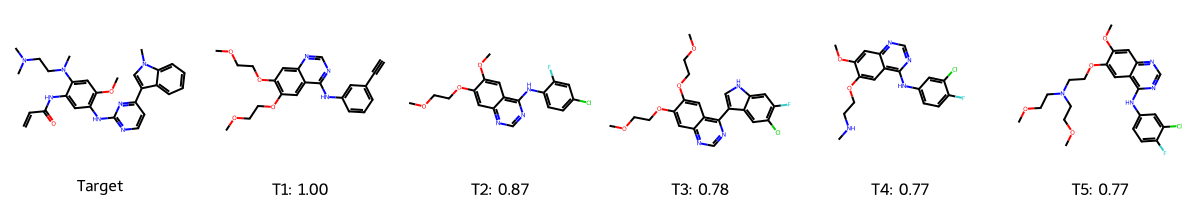

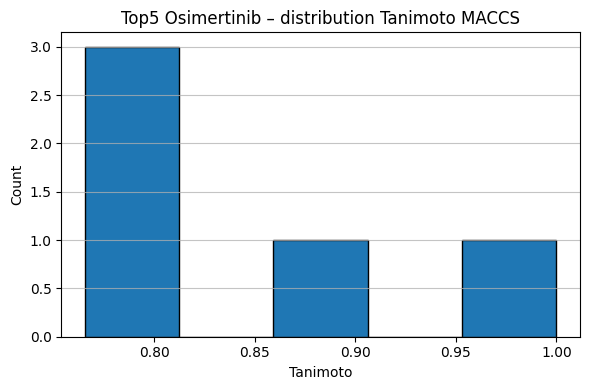

In [18]:
hits      = top10_maccs[['chembl_id','smiles_clean','tanimoto']].head(5)
hit_smis  = hits["smiles_clean"].tolist()
hit_scores= hits["tanimoto"].tolist()

# 7) Dessin cible vs hits
svg_str = draw_target_vs_hits(
    target_smiles=osi_smi,
    hits_smiles=hit_smis,
    scores=hit_scores,
    mols_per_row=6,
    sub_img_size=(200,200),
    legend_prefix="T"
)
display(SVG(data=svg_str))

# 8) Histogramme des scores
plot_similarity_histogram(
    hit_scores,
    bins=5,
    title="Top5 Osimertinib – distribution Tanimoto MACCS",
    xlabel="Tanimoto",
    ylabel="Count"
)

Overlap ECFP4 vs ECFP6: 9
Overlap ECFP4 vs MACCS: 3
Overlap ECFP6 vs MACCS: 3


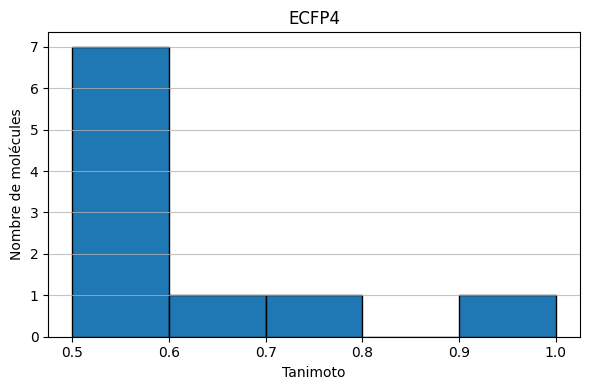

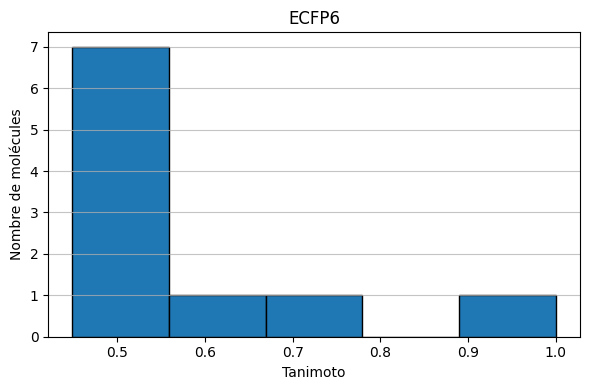

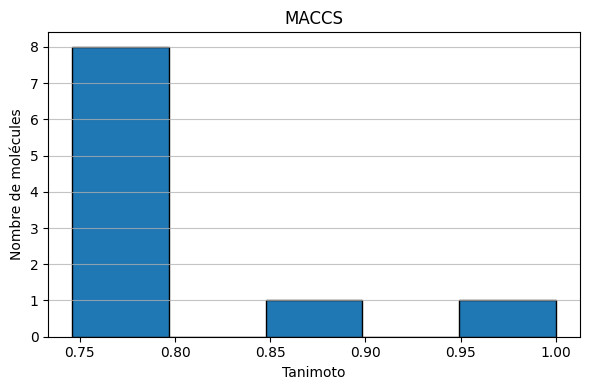

               rank4  rank6  rankm  consensus
chembl_id                                    
CHEMBL553        1.0    1.0    1.0        3.0
CHEMBL304929     2.0    2.0    8.0       12.0
CHEMBL3622632    3.0    3.0    6.0       12.0
CHEMBL286160     NaN    NaN    2.0        NaN
CHEMBL29197      7.0    6.0    NaN        NaN
CHEMBL293090     NaN    NaN    4.0        NaN
CHEMBL294395     NaN    NaN    5.0        NaN
CHEMBL29641      8.0    8.0    NaN        NaN
CHEMBL3622625    NaN   10.0    NaN        NaN
CHEMBL3828021    9.0    7.0    NaN        NaN


In [19]:
from pathlib import Path
import pandas as pd
import sys

sys.path.append("..")
from src.similarity import search_similar_compounds
from src.preprocessing import plot_similarity_histogram

# 1) Charger les données
ART = Path("artifacts")
DATA = Path("data")
df = pd.read_pickle(ART / "02_lib_filtered.pkl")
tkis = pd.read_csv(DATA / "tkis.csv")
erlo_smi = tkis.loc[tkis.name=="Erlotinib","smiles"].iloc[0]

# 2) Top‑10 pour chaque empreinte
top4 = search_similar_compounds(df, erlo_smi, fp_type='ecfp4', top_n=10)
top6 = search_similar_compounds(df, erlo_smi, fp_type='ecfp6', top_n=10)
topm = search_similar_compounds(df, erlo_smi, fp_type='maccs', top_n=10)

# 3) Intersection des ChEMBL IDs
set4 = set(top4.chembl_id)
set6 = set(top6.chembl_id)
setm = set(topm.chembl_id)

print("Overlap ECFP4 vs ECFP6:", len(set4 & set6))
print("Overlap ECFP4 vs MACCS:", len(set4 & setm))
print("Overlap ECFP6 vs MACCS:", len(set6 & setm))

# 4) Histogrammes de scores
plot_similarity_histogram(top4.tanimoto, bins=5, title="ECFP4")
plot_similarity_histogram(top6.tanimoto, bins=5, title="ECFP6")
plot_similarity_histogram(topm.tanimoto, bins=5, title="MACCS")

# 5) (Optionnel) Consensus ranking
all_hits = pd.concat([
    top4.assign(rank4=lambda d: range(1,len(d)+1)),
    top6.assign(rank6=lambda d: range(1,len(d)+1)),
    topm.assign(rankm=lambda d: range(1,len(d)+1))
]).groupby('chembl_id')\
 .agg({'rank4':'mean','rank6':'mean','rankm':'mean'})\
 .assign(consensus=lambda d: d.rank4 + d.rank6 + d.rankm)\
 .sort_values('consensus')\
 .head(10)
print(all_hits)


In [25]:
# %% [code]
import sys
from pathlib import Path
import pandas as pd
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from IPython.display import display

# 1) Pour importer src/
sys.path.append("..")

# 2) Fonctions de preprocessing pour calculer les RO5
from src.preprocessing import calculate_ro5_descriptors

# 3) Chemins
DATA_DIR = Path("data")
ART_DIR  = Path("artifacts")

# 4) Charger Top50 d’Erlotinib et le ranking consensus
top50_erlo = pd.read_csv(ART_DIR / "03_top50_Erlotinib.csv")
# all_hits vient du cell précédent (consensus). Si tu ne l’as pas encore dans l’environnement :
# Réévalue la partie consensus (voir code fourni plus haut).
# Ici on suppose que `all_hits` est déjà un DataFrame indexé par chembl_id
# avec une colonne 'consensus'.
# Si ce n’est pas le cas, réexécute la cellule “Optionnel) Consensus ranking”.

# 5) Sélection des 3 candidats consensus
cids = ["CHEMBL553", "CHEMBL304929", "CHEMBL3622632"]

# 6) Construction liste de dicts
records = []
for cid in cids:
    # SMILES nettoyés
    smi = top50_erlo.loc[top50_erlo["chembl_id"] == cid, "smiles_clean"].iloc[0]
    # descripteurs RO5
    desc = calculate_ro5_descriptors(smi)
    # scaffold Murcko
    scaffold = Chem.MolToSmiles(
        MurckoScaffold.GetScaffoldForMol(Chem.MolFromSmiles(smi)), 
        True
    )
    # score consensus moyen
    tan_mean = all_hits.loc[cid, "consensus"]
    
    records.append({
        "chembl_id": cid,
        "MW":            desc["MW"],
        "LogP":          desc["LogP"],
        "HBA":           desc["HBA"],
        "HBD":           desc["HBD"],
        "tanimoto_consensus": tan_mean,
        "scaffold":      scaffold
    })

# 7) Création du DataFrame final
summary = pd.DataFrame(records).set_index("chembl_id")

# 8) Affichage
display(summary)


,MW,LogP,HBA,HBD,tanimoto_consensus,scaffold
chembl_id,,,,,,
CHEMBL553,393.443,3.4051,7,1,3.0,c1ccc(Nc2ncnc3ccccc23)cc1
CHEMBL304929,305.337,3.3719,5,1,12.0,c1ccc(Nc2ncnc3ccccc23)cc1
CHEMBL3622632,445.523,3.4362,7,2,12.0,c1ccc(Nc2ncnc3ccccc23)cc1


In [26]:
# %% [code]
import sys
from pathlib import Path
import pandas as pd
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from IPython.display import display
sys.path.append("..")

# Imports
from src.similarity import search_similar_compounds
from src.preprocessing import calculate_ro5_descriptors

# Chemins
DATA_DIR = Path("data")
ART_DIR  = Path("artifacts")

# Charge le CSV des TKI
tkis = pd.read_csv(DATA_DIR / "tkis.csv")

# Liste où on stockera les résumés de chaque TKI
all_summaries = []

# Pour chaque TKI, on bouclera
for _, row in tkis.iterrows():
    name = row["name"]
    smi  = row["smiles"]
    print(f"--- Processing {name} ---")
    
    # 1) Top10 selon chaque empreinte
    top4 = search_similar_compounds(
        pd.read_pickle(ART_DIR/"02_lib_filtered.pkl"),
        query_smiles=smi,
        fp_type='ecfp4', metric='tanimoto', top_n=10
    )
    top6 = search_similar_compounds(
        pd.read_pickle(ART_DIR/"02_lib_filtered.pkl"),
        query_smiles=smi,
        fp_type='ecfp6', metric='tanimoto', top_n=10
    )
    topm = search_similar_compounds(
        pd.read_pickle(ART_DIR/"02_lib_filtered.pkl"),
        query_smiles=smi,
        fp_type='maccs', metric='tanimoto', top_n=10
    )
    
    # 2) Intersection des chembl_id pour obtenir les hits robustes
    s4, s6, sm = set(top4.chembl_id), set(top6.chembl_id), set(topm.chembl_id)
    consensus_ids = list(s4 & s6 & sm)
    
    # 3) Pour chaque consensual hit, extraire props & scaffold
    for cid in consensus_ids:
        # SMILES nettoyé du hit
        df_hits = top4  # on peut prendre n'importe quel topX, ils partagent les same chembl_id
        hit_smi = df_hits.loc[df_hits.chembl_id==cid, "smiles_clean"].iloc[0]
        
        # Descripteurs Lipinski
        desc = calculate_ro5_descriptors(hit_smi)
        
        # Scaffold Murcko
        scaffold = Chem.MolToSmiles(
            MurckoScaffold.GetScaffoldForMol(Chem.MolFromSmiles(hit_smi)),
            True
        )
        
        all_summaries.append({
            "TKI":        name,
            "chembl_id":  cid,
            "MW":         desc["MW"],
            "LogP":       desc["LogP"],
            "HBA":        desc["HBA"],
            "HBD":        desc["HBD"],
            "scaffold":   scaffold
        })

# 4) Assemblage du tableau final
summary_df = pd.DataFrame(all_summaries)
display(summary_df)


--- Processing Erlotinib ---
--- Processing Gefitinib ---
--- Processing Afatinib ---
--- Processing Osimertinib ---


,TKI,chembl_id,MW,LogP,HBA,HBD,scaffold
0,Erlotinib,CHEMBL553,393.443,3.40510,7,1,c1ccc(Nc2ncnc3ccccc23)cc1
1,Erlotinib,CHEMBL304929,305.337,3.37190,5,1,c1ccc(Nc2ncnc3ccccc23)cc1
2,Erlotinib,CHEMBL3622632,445.523,3.43620,7,2,c1ccc(Nc2ncnc3ccccc23)cc1
3,Gefitinib,CHEMBL14699,432.883,3.88550,7,1,c1ccc(Nc2ncnc3ccc(OCCN4CCOCC4)cc23)cc1
4,Gefitinib,CHEMBL24137,446.910,4.27560,7,1,c1ccc(Nc2ncnc3cc(OCCCN4CCOCC4)ccc23)cc1
5,Afatinib,CHEMBL2347958,485.947,4.38990,7,2,c1ccc(Nc2ncnc3cc(O[C@@H]4CCOC4)ccc23)cc1
6,Afatinib,CHEMBL4759112,485.947,4.38990,7,2,c1ccc(Nc2ncnc3ccc(O[C@@H]4CCOC4)cc23)cc1
7,Afatinib,CHEMBL3622639,473.936,4.24740,7,2,c1ccc(Nc2ncnc3ccccc23)cc1
8,Afatinib,CHEMBL3647422,499.974,4.78000,7,2,O=C(/C=C/[C@H]1CCCN1)Nc1ccc2ncnc(Nc3ccccc3)c2c1
9,Afatinib,CHEMBL3622629,428.851,4.45810,6,2,c1ccc(Nc2ncnc3cc(O[C@H]4CCOC4)ccc23)cc1
